In [1]:
from statistics import LinearRegression

## Acest dataset contine informatii legate de intarzierile trenurilor de pe reteaua feroviara din Polonia.
## Datele sunt organizate in acest set de date in felul urmator: datetime - data la care a fost inregistrata intarzierea, id - identificatorul trenului, date - data la care trenul pleaca din prima gara, connection - ruta pe care opereaza trenul, carrier - operatorul feroviar, arrival - ora la care trebuie sa ajunga in statia terminus, ##delay - intarzierea, name - numele garii

## Acest dataset acopera reteaua feroviara timp de doua saptamani, intre 12AM 16.05.2022 si 12AM 30.05.2022. Observatiile, mai precis datele, au fost colectate intr-un interval de 5 minute.


## Pentru D1 trebuie sa exploram dataset-ul.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from sklearn.metrics import mean_absolute_error

print(sys.executable)

C:\Users\todit\.conda\envs\PolishTrainDelaysML\python.exe


In [2]:
df = pd.read_csv("data/delays.csv")
print(pd.__version__) ##testare pandas
print(np.__version__) ##testare numpy

3.0.1
2.4.4


In [3]:
print(df) ##testare conexiune cu dataset

                    datetime                      id             carrier  \
0        2022-05-16 00:00:00   41002/3 (102) POLONIA       PKP Intercity   
1        2022-05-16 00:00:00          91888/9 (102)   Koleje Mazowieckie   
2        2022-05-16 00:00:00          21644/5 (102)   Koleje Mazowieckie   
3        2022-05-16 00:00:00          19300/1 (102)   Koleje Mazowieckie   
4        2022-05-16 00:00:00  38170/1 (102) USTRONIE       PKP Intercity   
...                      ...                     ...                 ...   
3718165  2022-05-29 23:55:00        53172/3  ROZEWIE       PKP Intercity   
3718166  2022-05-29 23:55:00                 15417    Koleje Mazowieckie   
3718167  2022-05-29 23:55:00       38170/1  USTRONIE       PKP Intercity   
3718168  2022-05-29 23:55:00       83170/1  USTRONIE       PKP Intercity   
3718169  2022-05-29 23:55:00        35170/1  KARPATY       PKP Intercity   

               date                                connection arrival  \
0        2022-

In [4]:
print(df.shape)

(3718170, 8)


print(df.shape) afiseaza practic forma datasetului, mai precis numarul de randuri si numarul de coloane. In cazul nostru, sunt 3718170 de randuri si 8 coloane.

In [5]:
print(df.columns)

Index(['datetime', 'id', 'carrier', 'date', 'connection', 'arrival', 'delay',
       'name'],
      dtype='str')


print(df.columns) afiseaza coloanele datasetului. In cazul nostru sunt 8 coloane, precizate in comment-ul din primul cell.

In [6]:
print(df.head())

              datetime                      id             carrier  \
0  2022-05-16 00:00:00   41002/3 (102) POLONIA       PKP Intercity   
1  2022-05-16 00:00:00          91888/9 (102)   Koleje Mazowieckie   
2  2022-05-16 00:00:00          21644/5 (102)   Koleje Mazowieckie   
3  2022-05-16 00:00:00          19300/1 (102)   Koleje Mazowieckie   
4  2022-05-16 00:00:00  38170/1 (102) USTRONIE       PKP Intercity   

         date                                connection arrival    delay  \
0  2022-05-15              Bohumin - Warszawa Wschodnia   21:31  162 min   
1  2022-05-16              Siedlce - Warszawa Zachodnia   00:15    0 min   
2  2022-05-16         Radom Główny - Warszawa Wschodnia   00:29    0 min   
3  2022-05-16  Warszawa Wschodnia - Grodzisk Mazowiecki   00:34    0 min   
4  2022-05-16                 Kraków Główny - Kołobrzeg   00:55    0 min   

                 name  
0  Warszawa Zachodnia  
1  Warszawa Zachodnia  
2  Warszawa Zachodnia  
3  Warszawa Zachodnia  
4 

Aici sunt afisate primele randuri din dataSet

In [7]:
print(df.describe())

                   datetime                 id        carrier        date  \
count               3718170            3718170        3718170     3718170   
unique                 4032               7947             10          16   
top     2022-05-20 06:15:00  38170/1  USTRONIE  PKP Intercity  2022-05-20   
freq                   1525              17567        1271352      283902   

               connection  arrival    delay      name  
count             3718170  3718170  3718170   3718170  
unique                995     1391      358        95  
top     Pruszków - Otwock    07:05    0 min  Żyrardów  
freq               138074     7861  2834968    124841  


Metoda .describe() are rolul de arata statisticile dataset-ului.

In [8]:
print(df.isnull().sum())

datetime      0
id            0
carrier       0
date          0
connection    0
arrival       0
delay         0
name          0
dtype: int64


Are rolul de arata valorile lipsa din dataset.

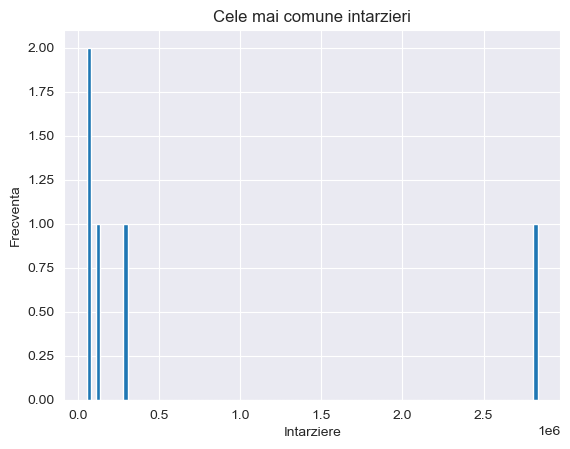

In [9]:
biggest_delays = df["delay"].value_counts().head()
biggest_delays.hist(bins=100)
plt.title("Cele mai comune intarzieri")
plt.xlabel("Intarziere")
plt.ylabel("Frecventa")
plt.show()

Grafic pentru cele mai frecvente intarzieri.

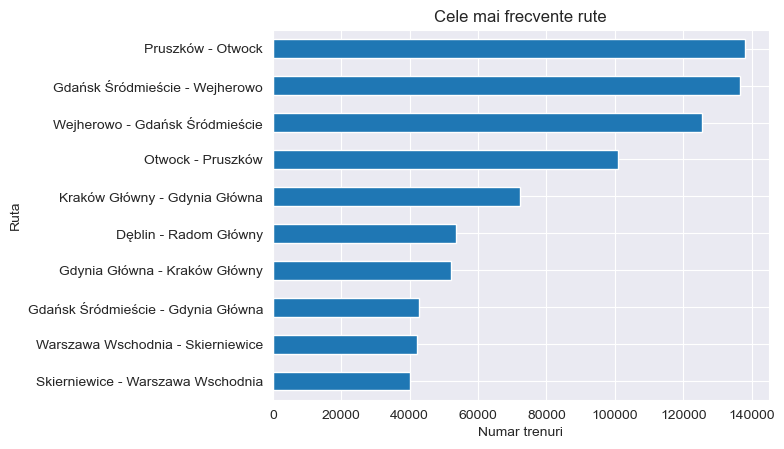

In [10]:
top_routes = df["connection"].value_counts().head(10)
top_routes.sort_values().plot(kind="barh")
plt.title("Cele mai frecvente rute")
plt.xlabel("Numar trenuri")
plt.ylabel("Ruta")
plt.show()



Cele mai frecvente trenuri de pe reteaua feroviara poloneza.

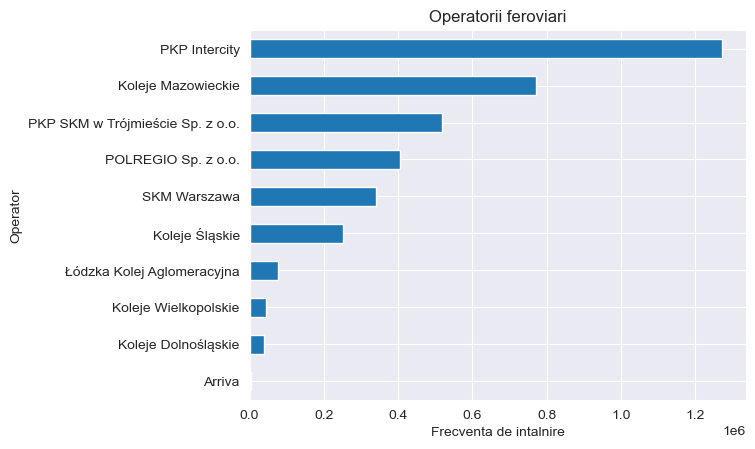

In [11]:
top_operators = df["carrier"].value_counts().head(10)
top_operators.sort_values().plot(kind="barh")
plt.title("Operatorii feroviari")
plt.xlabel("Frecventa de intalnire")
plt.ylabel("Operator")
plt.show()

Grafic care arata numarul de curse al fiecarui operator feroviar din Polonia. Nota : PKP Intercity este operatorul feroviar NATIONAL al Poloniei, restul sunt OTF privati.

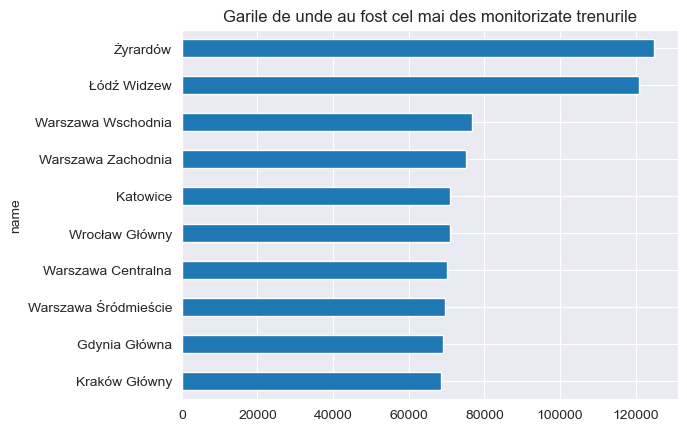

In [12]:
most_spots = df["name"].value_counts().head(10)
most_spots.sort_values().plot(kind="barh")
plt.title("Garile de unde au fost cel mai des monitorizate trenurile")
plt.show()

Grafic care determina garile unde au fost monitorizate trenurile, si mai precis unde au fost cel mai des monitorizate trenurile (primele 10 dupa numarul de aparitii)

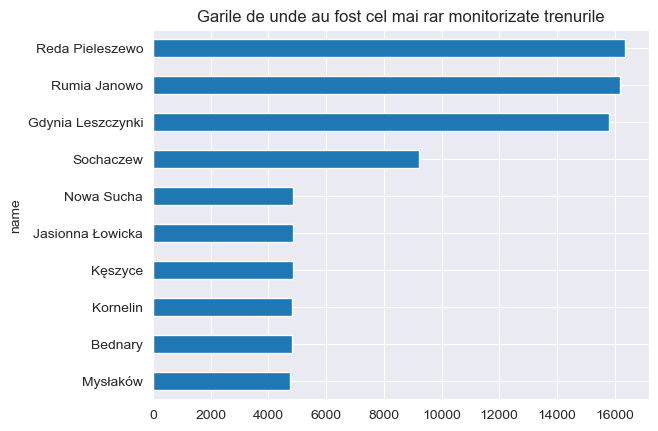

In [13]:
most_spots = df["name"].value_counts().tail(10)
most_spots.sort_values().plot(kind="barh")
plt.title("Garile de unde au fost cel mai rar monitorizate trenurile")
plt.show()

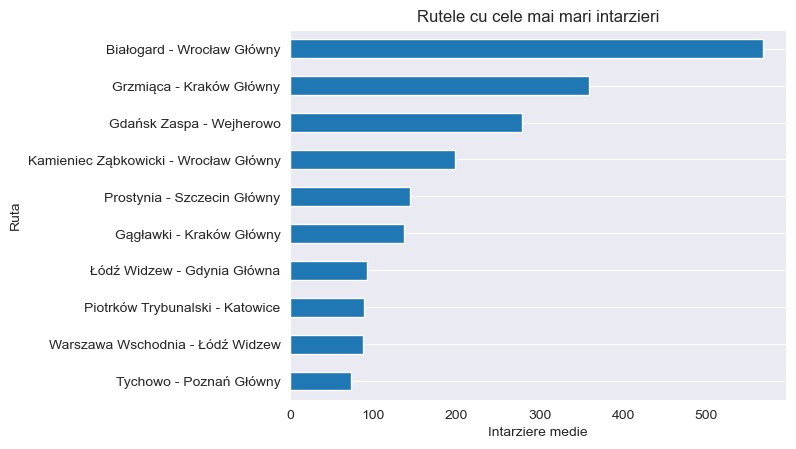

In [14]:
df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

top_delay_routes = (
    df.dropna(subset=["delay", "connection"])
    .groupby("connection")["delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_delay_routes.sort_values().plot(kind="barh")
plt.title("Rutele cu cele mai mari intarzieri")
plt.xlabel("Intarziere medie")
plt.ylabel("Ruta")
plt.grid(axis="x")
plt.show()



Aici sunt prezentate rutele care au cele mai mari intarzieri in medie. Conform acestui chart, ruta pe care sunt inregistrate cele mai mari intarzieri sunt Bialogard - Wroclaw Glowny, urmata de Grzmiaca - Krakow Glowny si de Gdansk Zaspa - Wejherowo.

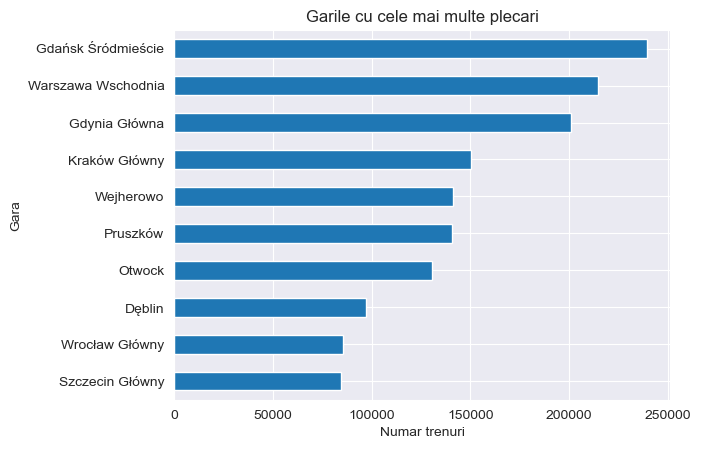

In [15]:
df["from"] = df["connection"].str.split("-").str[0].str.strip()

top_stations = df["from"].value_counts().head(10)
top_stations.sort_values().plot(kind="barh")
plt.xlabel("Numar trenuri")
plt.ylabel("Gara")
plt.title("Garile cu cele mai multe plecari")
plt.show()

In acest grafic sunt prezentate garile care au cele mai multe plecari. Conform acestui chart, gara din care pleaca cele mai multe trenuri este Gdansk Srodmiescie, urmata in top de Varsovia Wschodnia si Gdynia Glowna.

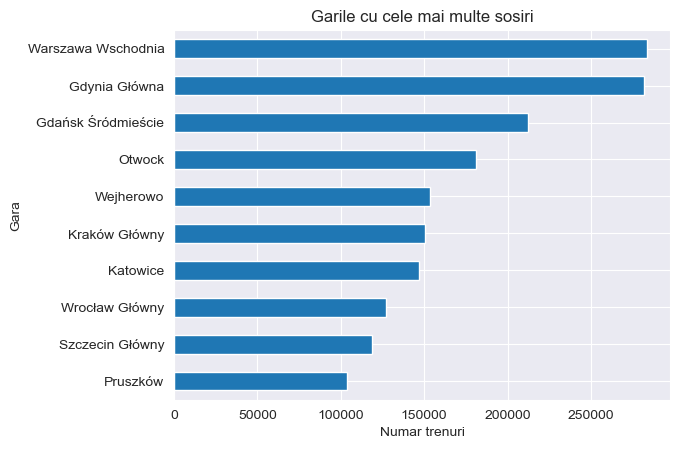

In [16]:
df["to"] = df["connection"].str.split("-").str[1].str.strip()

top_stations = df["to"].value_counts().head(10)
top_stations.sort_values().plot(kind="barh")
plt.xlabel("Numar trenuri")
plt.ylabel("Gara")
plt.title("Garile cu cele mai multe sosiri")
plt.show()

In acest grafic sunt prezentate garile care au cele mai multe sosiri. Conform acestui chart, gara in care sosesc cele mai multe trenuri este Varosiva Wschodnia, urmata in top de Gdynia Glowna si Gdansk Srodmiescie.

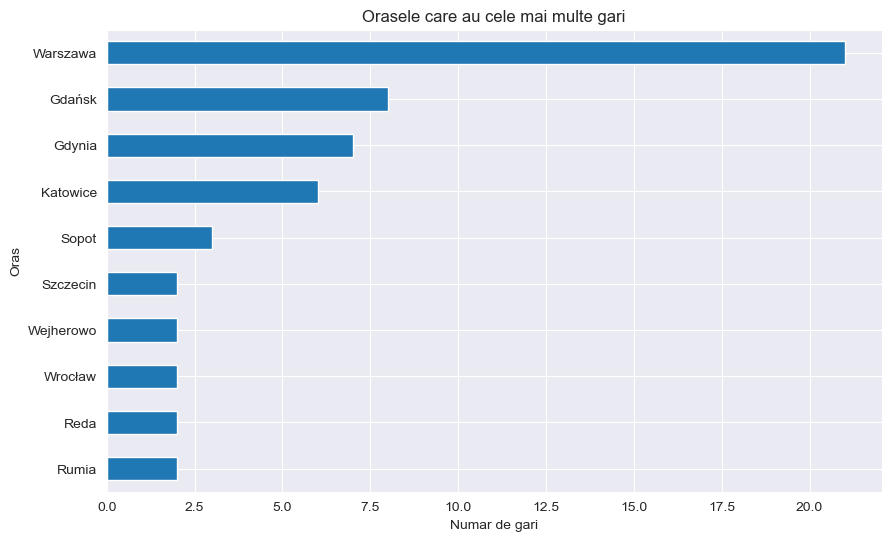

In [17]:
df["city"] = df["name"].str.split().str[0]
stations_per_city = df.groupby("city")["name"].nunique()

top_cities = stations_per_city.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_cities.sort_values().plot(kind="barh")
plt.title("Orasele care au cele mai multe gari")
plt.xlabel("Numar de gari")
plt.ylabel("Oras")
plt.show()


Conform acestui chart, cel mai important nod din reteaua feroviara poloneza este Varsovia, deoarece are cel mai mare numar de gari. Alte orase importante sunt Gdansk, Gdynia si Katowice.

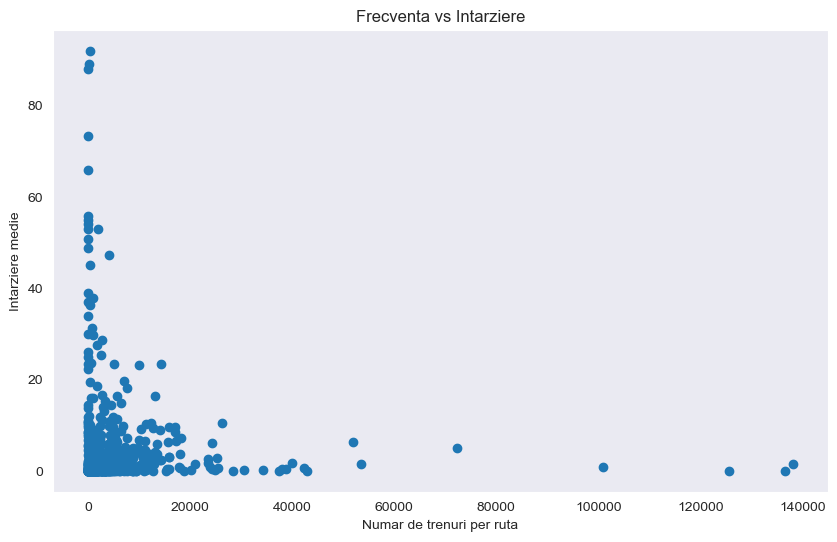

In [18]:
route_stats = df.groupby("connection")["delay"].agg(["mean", "count"])
filtered = route_stats[route_stats["mean"] < 100]
plt.figure(figsize=(10, 6))
plt.scatter(filtered["count"], filtered["mean"])

plt.xlabel("Numar de trenuri per ruta")
plt.ylabel("Intarziere medie")
plt.title("Frecventa vs Intarziere")

plt.grid()
plt.show()

Conform acestui grafic putem deduce ca nu exista o corelatie intre traficul ridicat pe o anumita ruta si intarzieri.


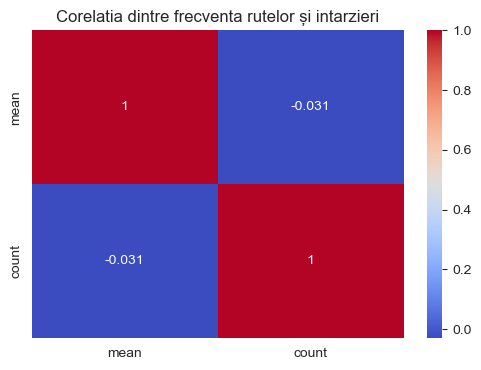

In [19]:
import seaborn as sns


df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

clean_df = df.dropna(subset=["connection", "delay"])


route_stats = df.groupby("connection")["delay"].agg(["mean", "count"])
plt.figure(figsize=(6,4))

sns.heatmap(route_stats.corr(), annot=True, cmap="coolwarm")

plt.title("Corelatia dintre frecventa rutelor și intarzieri")
plt.show()



Putem observa ca corelatia dintre frecventa si intarziere este aproape 0. Asta inseamna ca nu exista o corelatie intre traficul rutei si intarzierile aferente.Pe scurt, rutele foarte foarte populare nu sunt neaparat mai intarziate, iar rutele rare nu sunt neaparat mai rapide. Intarzierile sunt influentate de alti factori(infrastrucura deficitara, vreme, material rulant uzat, etc)

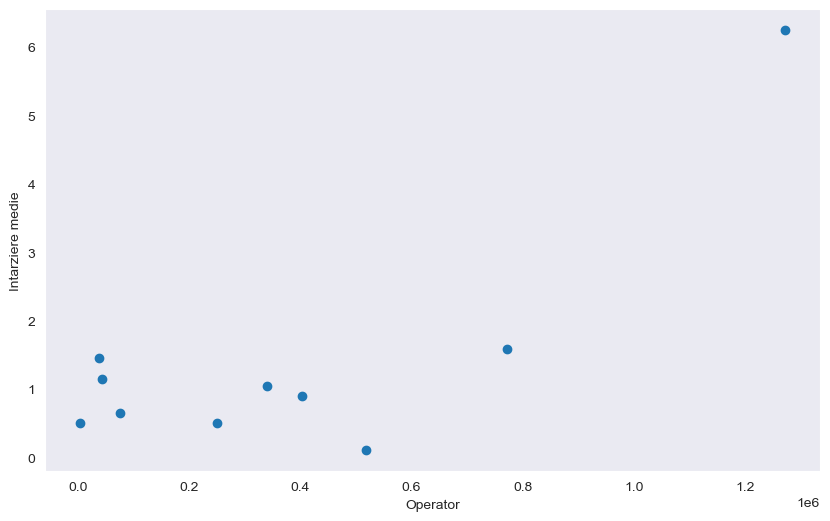

In [20]:
carrier_stats = df.groupby("carrier")["delay"].agg(["count", "mean"])
filtered_carrier = carrier_stats[carrier_stats["mean"] < 10]

plt.figure(figsize=(10, 6))
plt.scatter(filtered_carrier["count"], filtered_carrier["mean"])

plt.xlabel("Operator")
plt.ylabel("Intarziere medie")

plt.grid()
plt.show()


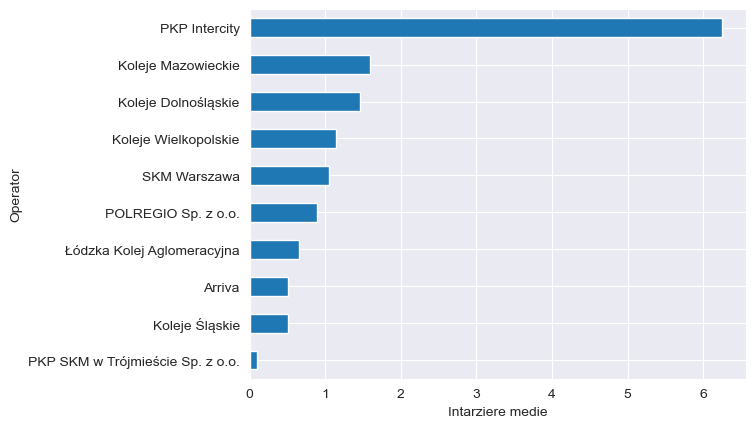

In [21]:
df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

top_delay_carriers = (

    df.dropna(subset=["delay", "carrier"])
    .groupby("carrier")["delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_delay_carriers.sort_values().plot(kind="barh")
plt.xlabel("Intarziere medie")
plt.ylabel("Operator")
plt.show()


PKP IC detine monopolul retelei de cale ferata din Polonia. Este compania nationala de stat din Polonia. Este normal, ca ei sa inregistreze grosul intarzierilor.

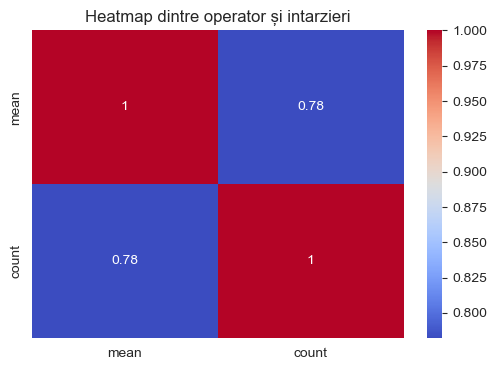

In [22]:
df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

clean_df = df.dropna(subset=["carrier", "delay"])


route_stats = df.groupby("carrier")["delay"].agg(["mean", "count"])
plt.figure(figsize=(6,4))

sns.heatmap(route_stats.corr(), annot=True, cmap="coolwarm")

plt.title("Heatmap dintre operator și intarzieri")
plt.show()

Operatorul feroviar (in cazul nostru PKP IC) poate fi considerat un predictor util in modelele de machine learning, chiar daca nu este neaparat cauza directa a intarzierilor.

Am analizat corelatia dintre numarul de trenuri operate si intarzierea medie. Rezultatele indica o corelatie pozitiva (0.78), sugerand ca operatorii cu un numar mare de trenuri tind sa aiba intarzieri mai mari.

Totusi, aceasta corelatie poate fi influentata de factori externi, precum complexitatea rutelor sau infrastructura utilizata.


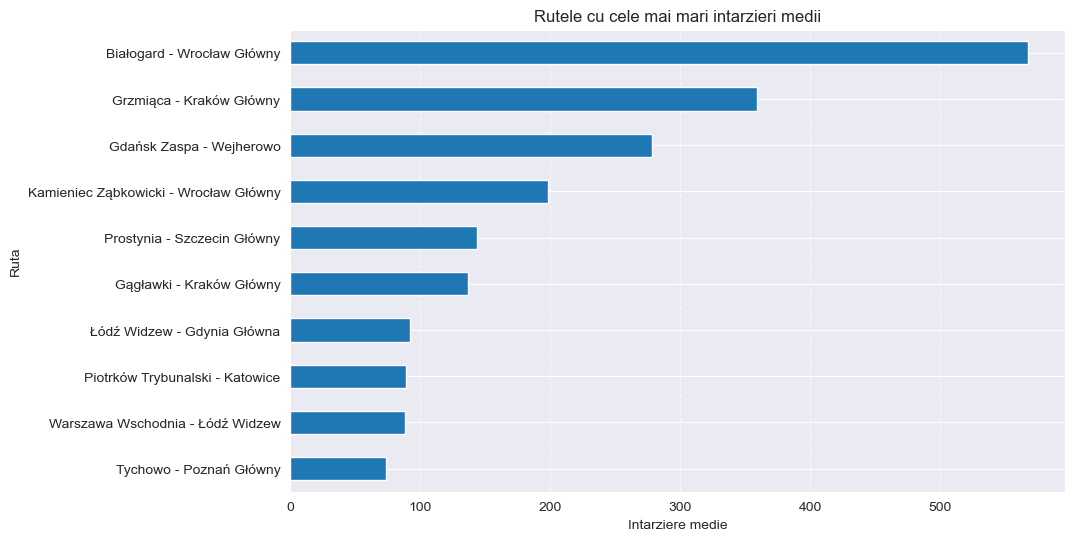

In [23]:
df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

top_delay_routes = (df.dropna(subset=["delay", "connection"]).groupby("connection")["delay"].mean().sort_values(ascending=False).head(10))

top_delay_routes.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Rutele cu cele mai mari intarzieri medii")
plt.xlabel("Intarziere medie")
plt.ylabel("Ruta")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

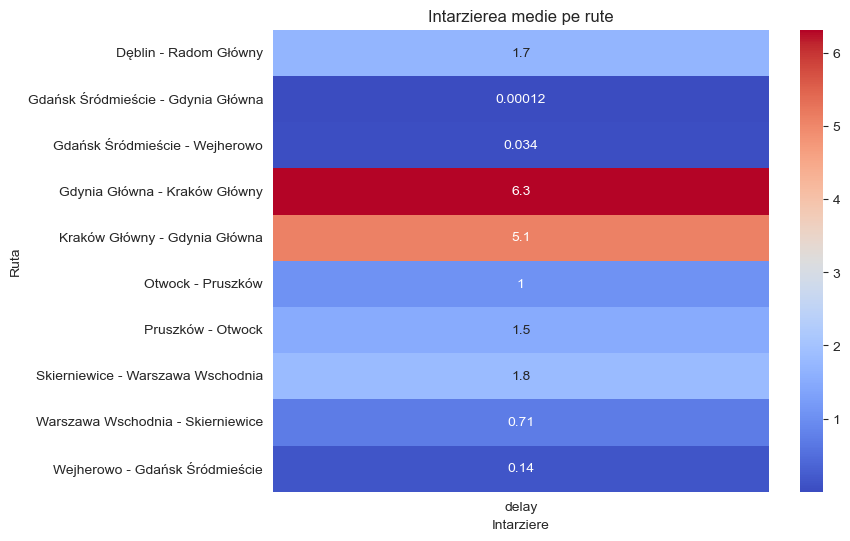

In [24]:
top_routes = df["connection"].value_counts().head(10).index

filtered = df[df["connection"].isin(top_routes)]

pivot = filtered.pivot_table(values = "delay", index = "connection", aggfunc = "mean")

plt.figure(figsize = (8, 6))
sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Intarzierea medie pe rute")
plt.xlabel("Intarziere")
plt.ylabel("Ruta")
plt.show()

Acest heatmap evidentiaza variatii semnificative ale intarzierilor intre diferite rute. Rutele lungi, precum Krakow-Gdynia, prezinta intarzieri medii ridicate, in timp ce rutele locale au intarzieri minime. De asemenea, se observa diferentele intre directiile aceleiasi rute, ceea ce sugereeaza influenta unor factori operationali specifici.

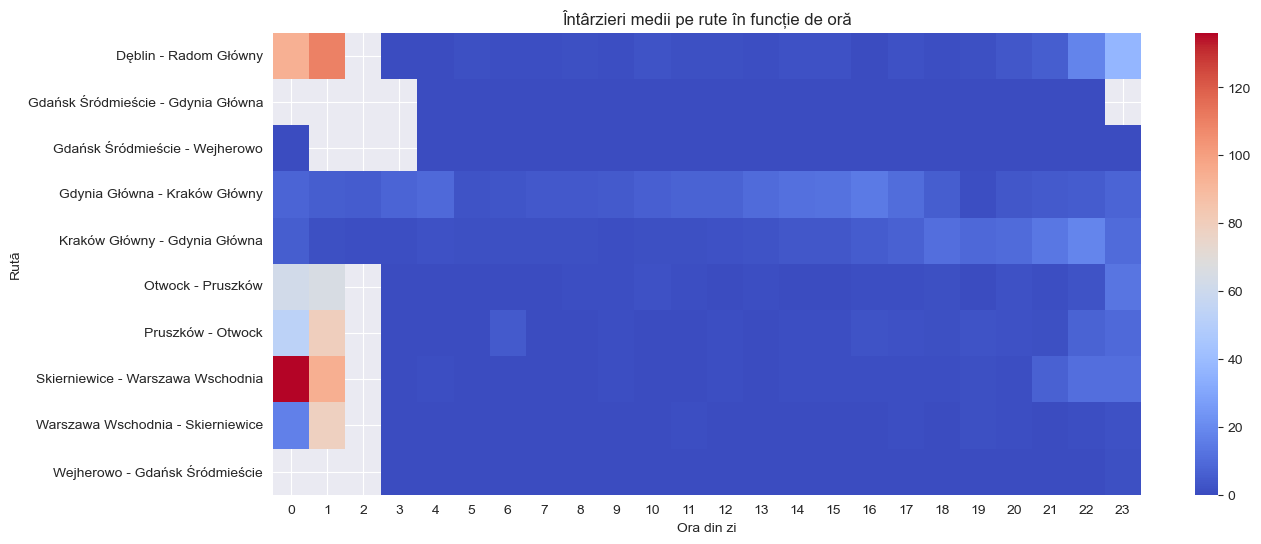

In [25]:
df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["hour"] = df["datetime"].dt.hour


top_routes = df["connection"].value_counts().head(10).index
filtered = df[df["connection"].isin(top_routes)]

pivot = filtered.pivot_table(values="delay", index = "connection", columns="hour" ,aggfunc = "mean")

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="coolwarm")

plt.title("Întârzieri medii pe rute în funcție de oră")
plt.xlabel("Ora din zi")
plt.ylabel("Rută")
plt.show()

Intarzierile depind atat de ruta, cat si de momentul zilei.

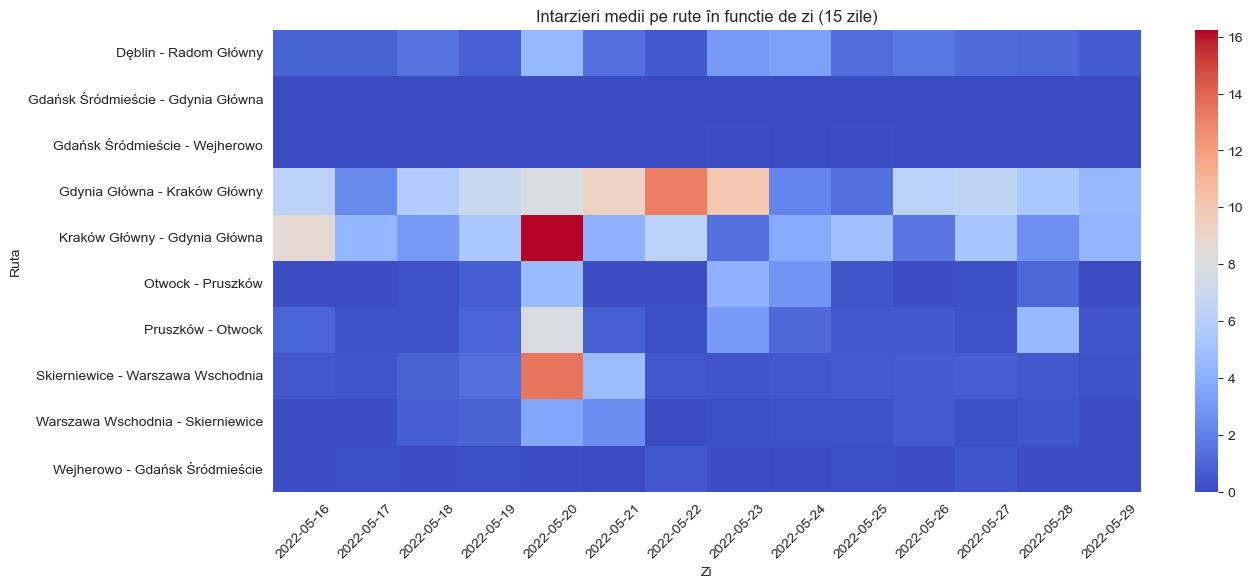

In [26]:
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["date_only"] = df["datetime"].dt.date

top_routes  = df["connection"].value_counts().head(10).index
filtered = df[df["connection"].isin(top_routes)]

pivot = filtered.pivot_table(
    values="delay",
    index="connection",
    columns="date_only",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="coolwarm")

plt.title("Intarzieri medii pe rute în functie de zi (15 zile)")
plt.xlabel("Zi")
plt.ylabel("Ruta")
plt.xticks(rotation=45)
plt.show()

In [27]:
def part_of_the_day(hour):
    if hour < 6:
        return "night"
    if hour < 12:
        return "morning"
    if hour < 16:
        return "afternoon"
    else:
        return "evening"

In [28]:
pd.to_datetime("2022-05-16").day_name()

'Monday'

In [29]:
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

df["day_of_week"] = df["datetime"].dt.dayofweek

df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

df[["datetime", "day_of_week", "is_weekend"]].head()

,datetime,day_of_week,is_weekend
0,2022-05-16,0,0
1,2022-05-16,0,0
2,2022-05-16,0,0
3,2022-05-16,0,0
4,2022-05-16,0,0


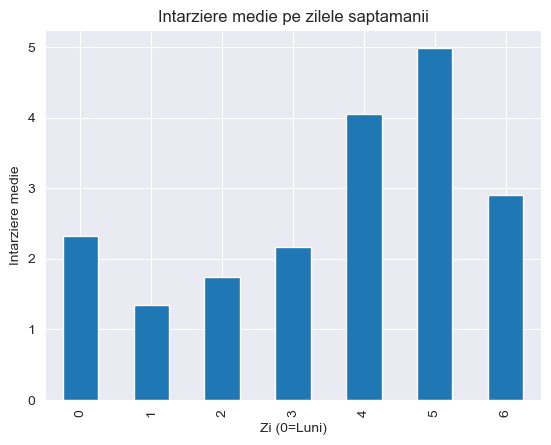

In [30]:
df.groupby("day_of_week")["delay"].mean().plot(kind="bar")

plt.title("Intarziere medie pe zilele saptamanii")
plt.xlabel("Zi (0=Luni)")
plt.ylabel("Intarziere medie")
plt.show()

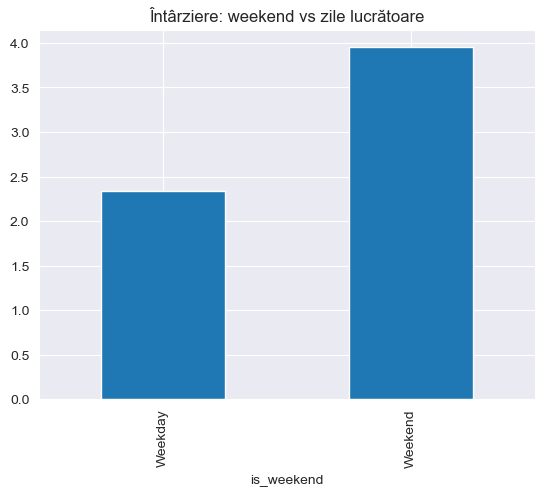

In [31]:
df.groupby("is_weekend")["delay"].mean().plot(kind="bar")

plt.xticks([0,1], ["Weekday", "Weekend"])
plt.title("Întârziere: weekend vs zile lucrătoare")
plt.show()

Conform acestor doua grafice, intarzierile cresc spre finalul saptamanii, atingand un maxim in preajma weekend-ului. In weekend, intarzierile sunt aproape duble fata de zilele lucratoare.

Analiza arata ca factorii temporali influenteaza semnificativ intarzierile trenurilor. Intarzierile cresc spre finalul saptamanii si sunt considierabili mai mari in weekend, comparativ cu zilele lucratoare. Acest comportament sugereaza ca tiparul de trafic si cererea influenteaza performanta transportului feroviar.

**LINEAR REGRESSION**



In aceasta parte ne ocupam de pregatirea datelor

In [32]:
df["delay"] = df["delay"].astype(str).str.extract(r"(\d+)")[0]
df["delay"] = pd.to_numeric(df["delay"], errors="coerce")

df = df.dropna(subset=["delay", "carrier","connection", "hour", "day_of_week"])

features = ["hour", "day_of_week", "is_weekend", "carrier"]

x = pd.get_dummies(df[features], drop_first=True)

y = df["delay"] ##encoding

Aici am pregatit datele, am ales feat-urile si am facut encoding-ul.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



Aici am facut Train/Test split.

Mai jos este algoritmul.

In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression: ")
print("MAE: ", mean_absolute_error(y_test, y_pred_lr))
print("R2: ", r2_score(y_test, y_pred_lr))

Linear Regression: 
MAE:  4.362392658827639
R2:  0.039672019400639136


Regresia liniara a avut o performanta scazuta, cu un R^2 de aproximativ 0.04, indicand ca modelul nu reuseste sa captureze relatiile complexe dintre variabile.
Acest lucru sugereaza ca intarzierile trenurilor nu pot fi modelate folosind o relatie liniara simpla.

Daca R2 este mic atunci modelul este slab. **R2 = 0.0396** modelul este slab pentru LR.


Daca MAE este mare atunci predictiile sunt slabe. **MAE = 4.3623**, predictia este destul de slaba.

**DECISION TREE**

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))




Decision Tree:
MAE: 3.906679039145336
R2: 0.09538226509821957


Modelul Decision Tree a avut performante mai bune decat regresia liniara, cu o eroare medie de aproximativ 3.9 minute si un scor R2 de 0.095.

Aceasta imbunatatire sugereaza ca relatia dintre variabile si intarzieri nu este una liniara, iar modelele bazate pe reguli pot capta mai bine tiparele existente in date.

**Random Forest**

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest: ")
print("MAE: ", mean_absolute_error(y_test, y_pred_rf))
print("R2: ", r2_score(y_test, y_pred_rf))


Random Forest: 
MAE:  3.8999852607765186
R2:  0.09664768070385377


Modelul Random Forest a avut performante aproape identice cu Decision Tree. Diferenta dintre **Decision Tree si Random Forest** la R-score si Eroare este de aproximativ **0.01**.